In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import cv2
import os
import numpy as np
import pandas as pd
from skimage.measure import label, regionprops
from skimage.feature import graycomatrix, graycoprops
import matplotlib.pyplot as plt

In [15]:
PATH = "/content/drive/MyDrive/ProjetoVisComp/dataset"

TRAIN_FRESH = os.path.join(PATH,"train","freshoranges")
TRAIN_ROTTEN = os.path.join(PATH,"train","rottenoranges")

In [18]:
arquivo = os.listdir(TRAIN_FRESH)[0]

img = cv2.imread(os.path.join(TRAIN_FRESH, arquivo))
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

In [19]:
def segmentar_laranja(img_rgb):

    bgr = cv2.cvtColor(img_rgb,cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr,cv2.COLOR_BGR2HSV)

    sat = hsv[:, :, 1]

    _, mask = cv2.threshold(sat,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5, 5))

    mask = cv2.morphologyEx(mask,cv2.MORPH_OPEN,se,iterations=2)
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,se,iterations=3)

    lbl = label(mask > 0)
    props = regionprops(lbl)

    if len(props) == 0:
        return None

    maior = max(props,key=lambda r: r.area).label

    mask_final = (lbl == maior).astype(np.uint8) * 255

    return mask_final

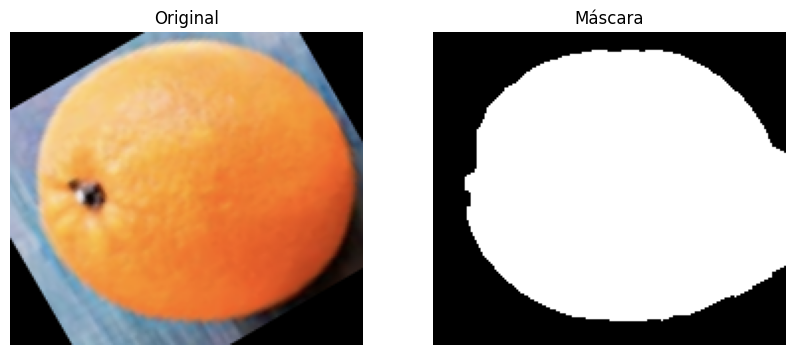

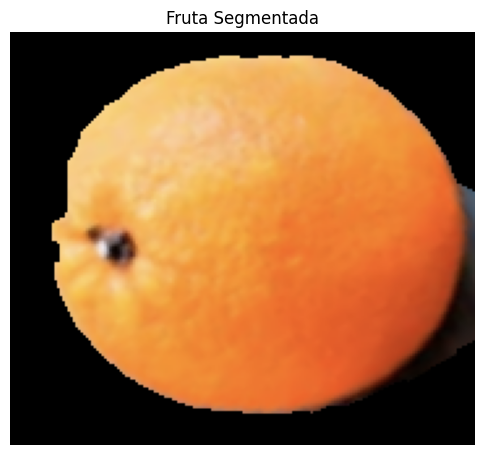

In [25]:
mask = segmentar_laranja(img_rgb)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Máscara")
plt.axis("off")

resultado = cv2.bitwise_and(img_rgb,img_rgb,mask=mask)

plt.figure(figsize=(6,6))
plt.imshow(resultado)
plt.title("Fruta Segmentada")
plt.axis("off")
plt.show()

In [26]:
def features_laranja(img_rgb):

    mask = segmentar_laranja(img_rgb)

    bgr = cv2.cvtColor(img_rgb,cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr,cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(bgr,cv2.COLOR_BGR2GRAY)

    pix = mask > 0
    lbl = label(pix)

    regioes = regionprops(lbl,intensity_image=gray)

    if len(regioes) == 0:
        return None

    r = max(regioes,key=lambda x: x.area)

    area = r.area
    perimeter = r.perimeter
    eccentricity = r.eccentricity
    solidity = r.solidity
    extent = r.extent
    circularidade = (4 * np.pi * area) / (perimeter**2)
    contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    maior = max(contours,key=cv2.contourArea)

    moments = cv2.moments(maior)
    hu = cv2.HuMoments(moments).flatten()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    H = hsv[:,:,0][pix]
    S = hsv[:,:,1][pix]
    V = hsv[:,:,2][pix]

    mean_h = H.mean()
    mean_s = S.mean()
    mean_v = V.mean()

    patch_gray = gray[r.slice].copy()
    patch_mask = pix[r.slice]
    valor_neutro = np.median(patch_gray[patch_mask])
    patch_gray[~patch_mask] = valor_neutro
    patch_q = (patch_gray // 32).astype(np.uint8)

    glcm = graycomatrix(
        patch_q,
        distances=[1],
        angles=[0,np.pi/4,np.pi/2,3*np.pi/4],
        levels=8,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm,'contrast').mean()
    homogeneity = graycoprops(glcm,'homogeneity').mean()
    energy = graycoprops(glcm,'energy').mean()
    correlation = graycoprops(glcm,'correlation').mean()

    return {
        "area": area,"perimeter": perimeter,
        "eccentricity": eccentricity,
        "solidity": solidity,
        "extent": extent,
        "circularidade": circularidade,
        "hu1": hu[0],
        "hu2": hu[1],
        "hu3": hu[2],
        "hu4": hu[3],
        "hu5": hu[4],
        "hu6": hu[5],
        "hu7": hu[6],
        "mean_h": mean_h,
        "mean_s": mean_s,
        "mean_v": mean_v,
        "contrast": contrast,
        "homogeneity": homogeneity,
        "energy": energy,
        "correlation": correlation
    }